In [1]:
import pandas as pd

In [2]:
test = pd.read_csv('archive/fraudTest.csv')
train = pd.read_csv("archive/fraudTrain.csv")

In [3]:
df = pd.merge(test,train,on="Unnamed: 0")

In [4]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [5]:
df["full name"]= df.first_x + " " + df.last_x

In [6]:
df = df[df.groupby("full name")["full name"].transform("count") > 1300]

In [7]:
df.head()

,trans_date_trans_time_x,cc_num_x,merchant_x,category_x,amt_x,first_x,last_x,gender_x,street_x,city_x,...,long_y,city_pop_y,job_y,dob_y,trans_num_y,unix_time_y,merch_lat_y,merch_long_y,is_fraud_y,full name
10,2020-06-21 12:16:20,2242542703101233,"fraud_Feil, Hilpert and Koss",food_dining,7.01,Samuel,Jenkins,M,43235 Mckenzie Views Apt. 837,Westport,...,-95.0380,7297,IT trainer,1990-07-13,d71c95ab6b7356dd74389d41df429c87,1325376383,40.275891,-96.011548,0,Samuel Jenkins
17,2020-06-21 12:19:50,4908846471916297,"fraud_Lang, Towne and Schuppe",kids_pets,16.60,Lauren,Torres,F,03030 White Lakes,Grandview,...,-87.3667,4081,Energy engineer,1938-03-15,f12cf52be2175703db789a4644c32f25,1325376658,38.674491,-88.305767,0,Lauren Torres
19,2020-06-21 12:20:13,6538441737335434,fraud_Prosacco LLC,personal_care,5.71,Gina,Grimes,F,444 Robert Mews,Clarks Mills,...,-74.2239,124967,Operational researcher,1980-12-21,09eff9c806365e2a6be12c1bbab3d70e,1325376754,40.079588,-74.848087,0,Gina Grimes
24,2020-06-21 12:21:47,372509258176510,"fraud_Watsica, Haag and Considine",shopping_pos,9.87,Kristen,Hanson,F,26544 Andrea Glen,Goodrich,...,-88.2196,95015,"Therapist, occupational",1946-01-02,d2432bfeabf142dc1bae1d426e32aecc,1325377086,43.375041,-89.055065,0,Kristen Hanson
31,2020-06-21 12:26:10,180048185037117,fraud_Ernser-Feest,home,134.39,Mary,Wall,F,2481 Mills Lock,Plainfield,...,-89.4649,5577,Geochemist,1964-12-30,cb598ec00d349dc95e7b3c18de5ae800,1325377359,36.294205,-89.811282,0,Mary Wall


In [8]:
df.columns

Index(['trans_date_trans_time_x', 'cc_num_x', 'merchant_x', 'category_x',
       'amt_x', 'first_x', 'last_x', 'gender_x', 'street_x', 'city_x',
       'state_x', 'zip_x', 'lat_x', 'long_x', 'city_pop_x', 'job_x', 'dob_x',
       'trans_num_x', 'unix_time_x', 'merch_lat_x', 'merch_long_x',
       'is_fraud_x', 'trans_date_trans_time_y', 'cc_num_y', 'merchant_y',
       'category_y', 'amt_y', 'first_y', 'last_y', 'gender_y', 'street_y',
       'city_y', 'state_y', 'zip_y', 'lat_y', 'long_y', 'city_pop_y', 'job_y',
       'dob_y', 'trans_num_y', 'unix_time_y', 'merch_lat_y', 'merch_long_y',
       'is_fraud_y', 'full name'],
      dtype='object')

In [9]:
df = df[
     [
    "full name",
    "is_fraud_y",
    "amt_y",
    "category_y"
]
]

In [10]:
df

,full name,is_fraud_y,amt_y,category_y
10,Samuel Jenkins,0,24.74,grocery_pos
17,Lauren Torres,0,341.67,shopping_pos
19,Gina Grimes,0,44.71,grocery_pos
24,Kristen Hanson,0,22.95,shopping_pos
31,Mary Wall,0,82.80,grocery_pos
...,...,...,...,...
555649,Crystal Gamble,0,47.61,grocery_net
555656,Sabrina Johnson,0,205.72,shopping_net
555657,Sharon Smith,0,4.39,travel
555662,Linda Davis,0,128.14,kids_pets


In [11]:
df = df.rename(columns={
    "full name": "Full Name",
    "is_fraud_y" : "Is Fraud",
    "amt_y" : "Amount",
    "category_y" : "Category"
})

In [12]:
df.head()

,Full Name,Is Fraud,Amount,Category
10,Samuel Jenkins,0,24.74,grocery_pos
17,Lauren Torres,0,341.67,shopping_pos
19,Gina Grimes,0,44.71,grocery_pos
24,Kristen Hanson,0,22.95,shopping_pos
31,Mary Wall,0,82.80,grocery_pos


In [13]:
df.tail()

,Full Name,Is Fraud,Amount,Category
555649,Crystal Gamble,0,47.61,grocery_net
555656,Sabrina Johnson,0,205.72,shopping_net
555657,Sharon Smith,0,4.39,travel
555662,Linda Davis,0,128.14,kids_pets
555671,Lori Ramirez,0,6.16,shopping_net


In [14]:
df.describe()

,Is Fraud,Amount
count,48273.000000,48273.000000
mean,0.006401,70.560218
std,0.079751,148.625898
min,0.000000,1.000000
25%,0.000000,9.630000
50%,0.000000,47.870000
75%,0.000000,83.190000
max,1.000000,10469.090000


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

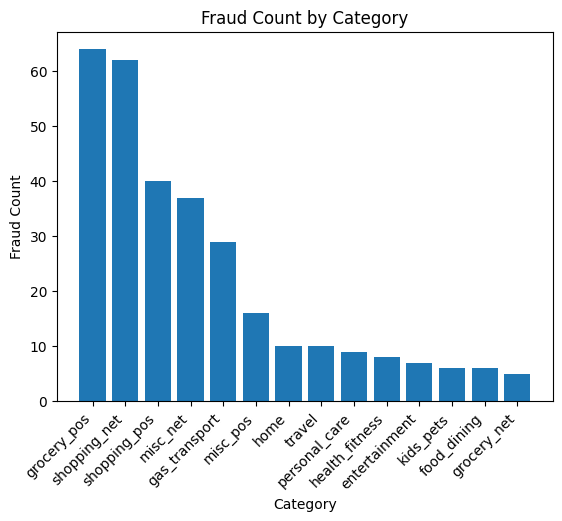

In [16]:
fraud_by_category = (
    df[df["Is Fraud"] == 1]["Category"]
    .value_counts()
)

plt.figure()
plt.bar(fraud_by_category.index, fraud_by_category.values)
plt.xlabel("Category")
plt.ylabel("Fraud Count")
plt.title("Fraud Count by Category")
plt.xticks(rotation=45, ha="right")
plt.show()


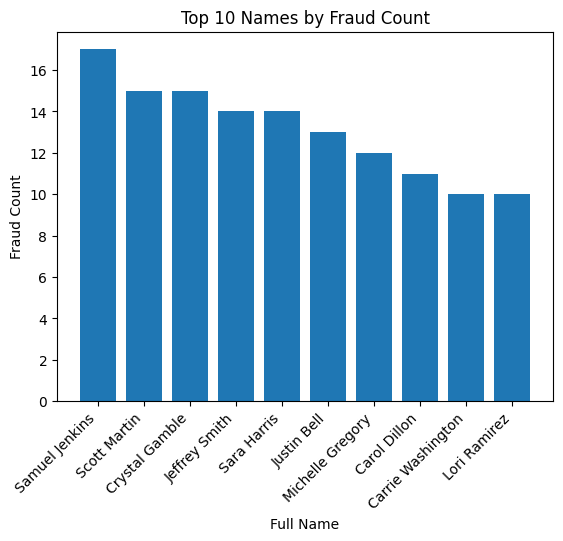

In [17]:
top_names = (
    df[df["Is Fraud"] == 1]["Full Name"]
    .value_counts()
    .head(10)
)

plt.figure()
plt.bar(top_names.index, top_names.values)
plt.xlabel("Full Name")
plt.ylabel("Fraud Count")
plt.title("Top 10 Names by Fraud Count")
plt.xticks(rotation=45, ha="right")
plt.show()


In [18]:
from sklearn.preprocessing import LabelEncoder
import json

name_encoder = LabelEncoder()
category_encoder = LabelEncoder()

df['Full Name'] = name_encoder.fit_transform(df['Full Name'])
df['Category'] = category_encoder.fit_transform(df['Category'])

name_to_number = dict(zip(name_encoder.classes_, range(len(name_encoder.classes_))))
category_to_number = dict(zip(category_encoder.classes_, range(len(category_encoder.classes_))))

with open('name_encoding.json', 'w') as f:
    json.dump(name_to_number, f, indent=2)

with open('category_encoding.json', 'w') as f:
    json.dump(category_to_number, f, indent=2)


In [19]:
x = df.drop("Is Fraud", axis=1)
y = df["Is Fraud"]

In [20]:
from imblearn.over_sampling import SMOTE

x_smote, y_smote = SMOTE().fit_resample(x, y)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Logistic Regression Accuracy: 0.8303450432607109
              precision    recall  f1-score   support

           0       0.77      0.95      0.85      9593
           1       0.93      0.71      0.81      9593

    accuracy                           0.83     19186
   macro avg       0.85      0.83      0.83     19186
weighted avg       0.85      0.83      0.83     19186



/Volumes/CrucialX9/Project/Data Science/number/Credit Card Fraud Detection Dataset/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Volumes/CrucialX9/Project/Data Science/number/Credit Card Fraud Detection Dataset/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Volumes/CrucialX9/Project/Data Science/number/Credit Card Fraud Detection Dataset/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Volumes/CrucialX9/Project/Data Science/number/Credit Card Fraud Detection Dataset/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Volumes/CrucialX9/Proje

In [23]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=200, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.9825393516105494
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      9593
           1       0.98      0.99      0.98      9593

    accuracy                           0.98     19186
   macro avg       0.98      0.98      0.98     19186
weighted avg       0.98      0.98      0.98     19186



In [24]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train, y_train)

y_pred = gbc.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Gradient Boosting Accuracy: 0.9555926196184718
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      9593
           1       0.96      0.95      0.96      9593

    accuracy                           0.96     19186
   macro avg       0.96      0.96      0.96     19186
weighted avg       0.96      0.96      0.96     19186



In [25]:
from sklearn.neighbors import KNeighborsClassifier

knc = KNeighborsClassifier(n_neighbors=5)
knc.fit(X_train, y_train)

y_pred = knc.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

KNN Accuracy: 0.9737308454081101
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      9593
           1       0.96      0.99      0.97      9593

    accuracy                           0.97     19186
   macro avg       0.97      0.97      0.97     19186
weighted avg       0.97      0.97      0.97     19186



In [26]:
import joblib

joblib.dump(rfc, "credit_card.joblib")


['credit_card.joblib']